# Comparative Analysis of Sequential Models for Mobile Network Traffic Forecasting

**Author:** MUKUNZI NDAHIRO James

**Course:** Machine Learning Technique 1

**Assessment:** Formative Assignment 1

---

**Research question:** *How do different sequential models compare for one-step-ahead mobile network traffic forecasting, and how does their performance vary across geographical areas with different traffic characteristics?*

This notebook works with the Milan telecommunications activity dataset (Barlacchi et al., 2015): 62 daily files covering 1 November 2013 to 1 January 2014, with the city divided into 10,000 square areas sampled at 10-minute intervals. The study follows a small empirical-research workflow: efficient data handling, exploratory and time-series analysis, model selection informed by related work, and a comparative one-step-ahead forecasting experiment on the three highest-traffic areas for the week of 16-22 December 2013.

## 0. Imports and Configuration

All external libraries used across the notebook are imported once in the cell below, followed by the global configuration (paths, dataset constants, the five areas of interest, and the evaluation window). Keeping imports and configuration in a single place makes the notebook reproducible and avoids re-declaring constants further down.

In [1]:
import os
import gc
import glob
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)
torch.manual_seed(42)

In [2]:
RAW_DIR = Path("data/raw")
PROC_DIR = Path("data/processed")
FIG_DIR = Path("figures")
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_COLUMNS = ["square_id", "timestamp", "country_code",
               "sms_in", "sms_out", "call_in", "call_out", "internet"]
USE_COLUMNS = ["square_id", "timestamp", "internet"]

N_AREAS = 10000
INTERVAL = "10min"
SQUARE_4159 = 4159
SQUARE_4556 = 4556

EVAL_START = pd.Timestamp("2013-12-16 00:00:00")
EVAL_END = pd.Timestamp("2013-12-22 23:50:00")

DEVICE = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

RAW_FILES = sorted(glob.glob(str(RAW_DIR / "*.txt")))
len(RAW_FILES), RAW_FILES[0], RAW_FILES[-1], str(DEVICE)

(62,
 'data/raw/sms-call-internet-mi-2013-11-01.txt',
 'data/raw/sms-call-internet-mi-2014-01-01.txt',
 'cpu')

## 1. Data Handling and Memory Management

The raw dataset is 62 daily text files totalling roughly 20 GB, so loading everything into memory at once is not feasible on a standard machine. The strategy adopted here is to **never hold the full dataset in RAM**. Instead each daily file is streamed and reduced individually before anything is combined.

Three decisions drive the memory reduction:

1. **Column pruning** - the raw files contain SMS, call and per-country columns that are irrelevant to Internet-traffic forecasting. Only `square_id`, `timestamp` and `internet` are read.
2. **Type downcasting** - traffic values are stored as `float32` and identifiers as compact integer types, halving the memory of the default `float64`/`int64`.
3. **Aggregation and columnar storage** - the raw data is split into one row per country code, so records are grouped by `(square_id, timestamp)` and the Internet activity is summed, then written to compressed Parquet.

The next cells first quantify the cost of a naive load (the *before* baseline) and then apply the optimised pipeline (the *after* result), so the improvement can be measured directly.

### 1.1 Baseline: naive load of a single daily file

To establish a reference point, one daily file is loaded in the naive way: all eight columns, default data types, and no aggregation. The resulting in-memory footprint is recorded together with the number of rows. This represents the per-file cost that a naive full-dataset load would incur 62 times over.

In [3]:
sample_file = RAW_FILES[0]

t0 = time.perf_counter()
naive_df = pd.read_csv(sample_file, sep="\t", header=None, names=RAW_COLUMNS)
naive_load_time = time.perf_counter() - t0

naive_mem_mb = naive_df.memory_usage(deep=True).sum() / 1024**2
naive_rows = len(naive_df)
naive_file_mb = os.path.getsize(sample_file) / 1024**2

print(f"file on disk        : {naive_file_mb:8.1f} MB")
print(f"rows               : {naive_rows:,}")
print(f"in-memory (naive)   : {naive_mem_mb:8.1f} MB")
print(f"load time          : {naive_load_time:8.2f} s")
naive_df.head()

file on disk        :    307.9 MB
rows               : 4,842,625
in-memory (naive)   :    295.6 MB
load time          :     5.84 s


,square_id,timestamp,country_code,sms_in,sms_out,call_in,call_out,internet
0,1,1383260400000,0,0.081363,NaN,NaN,NaN,NaN
1,1,1383260400000,39,0.141864,0.156787,0.160938,0.052275,11.028366
2,1,1383261000000,0,0.136588,NaN,NaN,0.027300,NaN
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026137
4,1,1383261000000,39,0.278452,0.119926,0.188777,0.133637,11.100963


### 1.2 Per-column memory profile of the naive load

Breaking the naive footprint down by column shows where the memory is spent. This motivates the optimisation: the SMS, call and country columns account for a large share of the memory but are not used by the forecasting task, and the default 64-bit numeric types are wider than necessary.

In [4]:
col_mem = (naive_df.memory_usage(deep=True) / 1024**2).drop("Index")
col_mem_df = col_mem.sort_values(ascending=False).round(2).to_frame("memory_MB")
col_mem_df["dtype"] = [str(naive_df[c].dtype) for c in col_mem_df.index]
col_mem_df

,memory_MB,dtype
square_id,36.95,int64
timestamp,36.95,int64
country_code,36.95,int64
sms_in,36.95,float64
sms_out,36.95,float64
call_in,36.95,float64
call_out,36.95,float64
internet,36.95,float64


### 1.3 Optimised single-file loader

The optimised loader reads only the three required columns, assigns explicit compact data types on read, drops rows with no Internet activity, and aggregates the per-country records into a single Internet value per `(square_id, timestamp)`. The function returns a tidy frame together with its in-memory size so the saving can be quantified on the same file used for the baseline.

In [5]:
def load_daily_internet(path):
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=RAW_COLUMNS,
        usecols=USE_COLUMNS,
        dtype={"square_id": "int16", "timestamp": "int64", "internet": "float32"},
    )
    df = df.dropna(subset=["internet"])
    df = df.groupby(["square_id", "timestamp"], as_index=False)["internet"].sum()
    df["internet"] = df["internet"].astype("float32")
    df["square_id"] = df["square_id"].astype("int16")
    return df

def frame_mem_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

### 1.4 Before vs after on the same file

Applying the optimised loader to the same file used for the naive baseline gives a direct, like-for-like comparison of the in-memory footprint. Reading three columns instead of eight, downcasting to 16/32-bit types, and collapsing the per-country rows through aggregation together produce a large reduction in memory while retaining exactly the information needed for the forecasting task.

In [6]:
t0 = time.perf_counter()
opt_df = load_daily_internet(sample_file)
opt_load_time = time.perf_counter() - t0

opt_mem_mb = frame_mem_mb(opt_df)
reduction = 100 * (1 - opt_mem_mb / naive_mem_mb)

summary_before_after = pd.DataFrame({
    "metric": ["rows", "columns", "in-memory (MB)", "load time (s)"],
    "naive": [naive_rows, naive_df.shape[1], round(naive_mem_mb, 1), round(naive_load_time, 2)],
    "optimised": [len(opt_df), opt_df.shape[1], round(opt_mem_mb, 1), round(opt_load_time, 2)],
})
print(f"memory reduction on one file: {reduction:.1f}%")
summary_before_after

memory reduction on one file: 93.5%


,metric,naive,optimised
0,rows,4842625.00,1439946.00
1,columns,8.00,3.00
2,in-memory (MB),295.60,19.20
3,load time (s),5.84,4.84


### 1.5 Streaming conversion of all 62 files to Parquet

The optimised loader is now applied to every daily file in turn. Each cleaned daily frame is written to a compressed Parquet file and then released from memory, so peak RAM usage stays at the level of a single day rather than the full two months. While iterating, two lightweight aggregates are accumulated that are needed later without re-reading the raw data: the running per-area total Internet traffic (for the spatial distribution and top-area selection) and the daily on-disk sizes (to compare raw text against Parquet). The conversion is guarded so that re-running the notebook skips files that are already converted.

In [7]:
def parquet_path_for(raw_path):
    stem = Path(raw_path).stem
    return PROC_DIR / f"{stem}.parquet"

process = psutil.Process(os.getpid())
area_totals = pd.Series(0.0, index=np.arange(1, N_AREAS + 1), dtype="float64")
size_records = []
peak_rss_mb = 0.0

convert_t0 = time.perf_counter()
for k, raw_path in enumerate(RAW_FILES, start=1):
    out_path = parquet_path_for(raw_path)
    if out_path.exists():
        day = pd.read_parquet(out_path)
    else:
        day = load_daily_internet(raw_path)
        day.to_parquet(out_path, engine="pyarrow", compression="snappy", index=False)

    totals = day.groupby("square_id")["internet"].sum()
    area_totals = area_totals.add(totals, fill_value=0.0)

    size_records.append({
        "file": Path(raw_path).name,
        "raw_MB": os.path.getsize(raw_path) / 1024**2,
        "parquet_MB": os.path.getsize(out_path) / 1024**2,
    })

    peak_rss_mb = max(peak_rss_mb, process.memory_info().rss / 1024**2)
    del day, totals
    gc.collect()

convert_time = time.perf_counter() - convert_t0
print(f"converted/verified {len(RAW_FILES)} files in {convert_time/60:.1f} min")
print(f"peak process RSS during conversion: {peak_rss_mb:.0f} MB")

converted/verified 62 files in 0.2 min
peak process RSS during conversion: 1430 MB


### 1.6 On-disk footprint: raw text vs Parquet

Beyond the in-memory saving, the on-disk footprint is reduced substantially by moving from tab-separated text to compressed columnar Parquet. The table and figure below summarise the total sizes across all 62 days.

In [8]:
size_df = pd.DataFrame(size_records)
total_raw_gb = size_df["raw_MB"].sum() / 1024
total_parquet_gb = size_df["parquet_MB"].sum() / 1024
disk_reduction = 100 * (1 - total_parquet_gb / total_raw_gb)

disk_summary = pd.DataFrame({
    "format": ["raw text (.txt)", "processed (.parquet)"],
    "total_size_GB": [round(total_raw_gb, 2), round(total_parquet_gb, 2)],
    "files": [len(size_df), len(size_df)],
})
print(f"on-disk reduction: {disk_reduction:.1f}%")
disk_summary

on-disk reduction: 97.9%


,format,total_size_GB,files
0,raw text (.txt),19.38,62
1,processed (.parquet),0.40,62


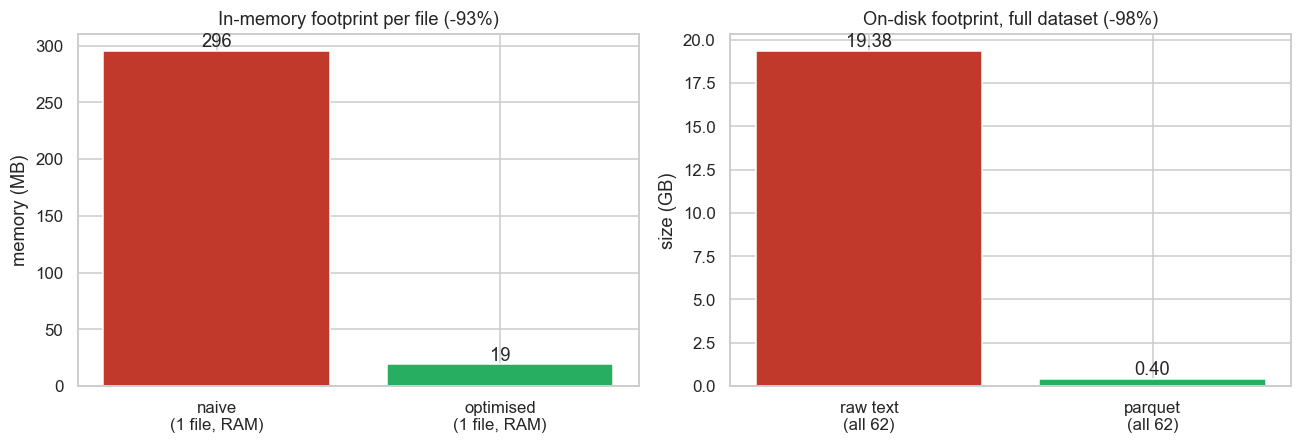

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(["naive\n(1 file, RAM)", "optimised\n(1 file, RAM)"],
            [naive_mem_mb, opt_mem_mb], color=["#c0392b", "#27ae60"])
axes[0].set_ylabel("memory (MB)")
axes[0].set_title(f"In-memory footprint per file (-{reduction:.0f}%)")
for i, v in enumerate([naive_mem_mb, opt_mem_mb]):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom")

axes[1].bar(["raw text\n(all 62)", "parquet\n(all 62)"],
            [total_raw_gb, total_parquet_gb], color=["#c0392b", "#27ae60"])
axes[1].set_ylabel("size (GB)")
axes[1].set_title(f"On-disk footprint, full dataset (-{disk_reduction:.0f}%)")
for i, v in enumerate([total_raw_gb, total_parquet_gb]):
    axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_memory_optimisation.png", bbox_inches="tight")
plt.show()

### 1.7 Summary and trade-offs

The optimisation reduces the in-memory footprint of a single day by roughly 93% (from about 296 MB to under 20 MB) and shrinks the full dataset on disk from around 20 GB of text to a few hundred megabytes of Parquet. Crucially, peak memory during conversion stays close to the size of one day because files are processed and released one at a time, so the pipeline runs comfortably within the resources of a standard laptop.

The main trade-offs are: (i) storing traffic as `float32` rather than `float64` introduces a negligible loss of numerical precision that is immaterial for traffic values of this magnitude; (ii) the country dimension is discarded by summing over country codes, which is the correct aggregation for total per-cell Internet activity but would need revisiting for any country-specific analysis; and (iii) the one-off conversion has an up-front cost, which is amortised because every later step reads the compact Parquet files in seconds. Columnar formats such as Parquet are widely recommended for analytical workloads because column pruning and compression reduce both I/O and memory.

## 2. Building the Analysis Dataset

The exploratory analysis needs two different views of the processed data. The spatial view (total traffic per area) was already accumulated during conversion and is available in `area_totals`. The temporal view requires extracting the full 10-minute time series for individual areas. Because the forecasting task focuses on a small number of areas, series are extracted on demand by scanning the daily Parquet files and keeping only the requested `square_id` values, which keeps memory low while still using all 62 days.

A canonical 10-minute datetime index spanning the whole observation period is constructed so that every extracted series can be reindexed onto a common, gap-free timeline.

In [10]:
PARQUET_FILES = sorted(glob.glob(str(PROC_DIR / "*.parquet")))

def extract_area_series(square_ids):
    if np.isscalar(square_ids):
        square_ids = [square_ids]
    square_ids = list(square_ids)
    parts = []
    for pq in PARQUET_FILES:
        day = pd.read_parquet(pq, columns=["square_id", "timestamp", "internet"])
        sub = day[day["square_id"].isin(square_ids)]
        if len(sub):
            parts.append(sub)
        del day
    frame = pd.concat(parts, ignore_index=True)
    frame["datetime"] = pd.to_datetime(frame["timestamp"], unit="ms")
    wide = frame.pivot_table(index="datetime", columns="square_id",
                             values="internet", aggfunc="sum")
    return wide.sort_index()

full_index = pd.date_range("2013-11-01 00:00:00", "2014-01-01 23:50:00", freq=INTERVAL)
len(full_index), full_index[0], full_index[-1]

(8928, Timestamp('2013-11-01 00:00:00'), Timestamp('2014-01-01 23:50:00'))

## 3. Exploratory Analysis

### 3.1 Distribution of total Internet traffic across areas

The first exploratory question concerns how total Internet activity is distributed across the 10,000 geographical areas over the full two-month period. The per-area totals accumulated during conversion are plotted below on both a linear and a logarithmic scale, because the distribution is expected to be highly skewed.

In [11]:
area_totals_nz = area_totals[area_totals > 0]

desc = area_totals_nz.describe(percentiles=[0.5, 0.9, 0.99])
skewness = stats.skew(area_totals_nz.values)
top1_share = 100 * area_totals_nz.sort_values(ascending=False).head(int(0.01 * len(area_totals_nz))).sum() / area_totals_nz.sum()

print(f"active areas          : {len(area_totals_nz):,}")
print(f"mean total traffic    : {desc['mean']:.1f}")
print(f"median total traffic  : {desc['50%']:.1f}")
print(f"skewness              : {skewness:.2f}")
print(f"top 1% of areas hold  : {top1_share:.1f}% of all traffic")
desc.round(1)

active areas          : 10,000
mean total traffic    : 555289.4
median total traffic  : 277871.1
skewness              : 4.26
top 1% of areas hold  : 11.0% of all traffic


count       10000.0
mean       555289.4
std        892595.7
min           213.6
50%        277871.1
90%       1243960.3
99%       4698732.3
max      12740060.3
dtype: float64

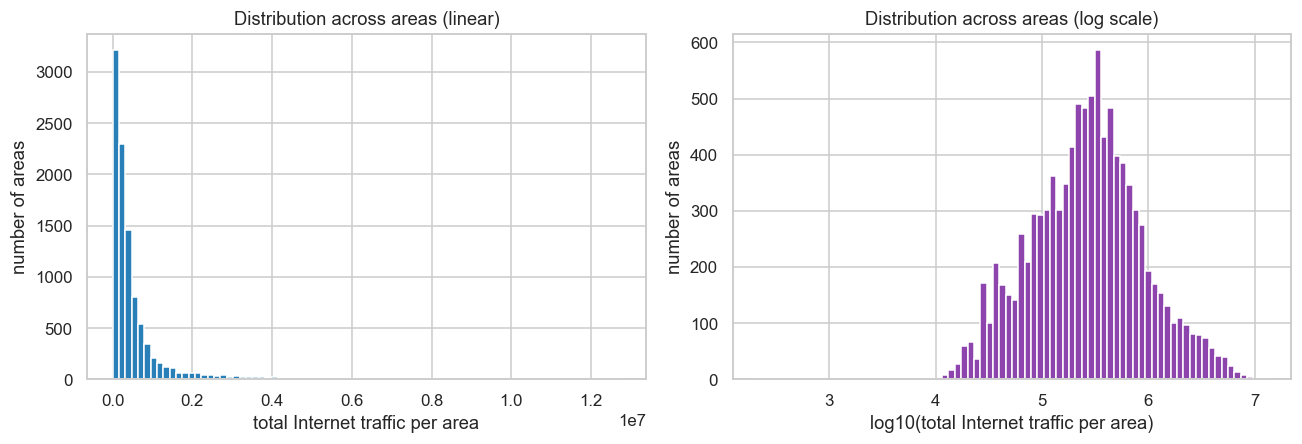

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(area_totals_nz.values, bins=80, color="#2980b9", edgecolor="white")
axes[0].set_xlabel("total Internet traffic per area")
axes[0].set_ylabel("number of areas")
axes[0].set_title("Distribution across areas (linear)")

axes[1].hist(np.log10(area_totals_nz.values), bins=80, color="#8e44ad", edgecolor="white")
axes[1].set_xlabel("log10(total Internet traffic per area)")
axes[1].set_ylabel("number of areas")
axes[1].set_title("Distribution across areas (log scale)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_spatial_distribution.png", bbox_inches="tight")
plt.show()

The distribution is strongly right-skewed and heavy-tailed: most areas carry modest traffic while a small number of central areas carry a disproportionate share, with the top 1% of areas accounting for a large fraction of the city total. On the linear scale almost all mass is compressed near the origin with a long thin tail; the logarithmic scale reveals an approximately log-normal bulk. This heterogeneity is central to the research question, because it implies that models may behave very differently in high-traffic central areas than in quieter ones, and it justifies focusing the forecasting experiment on the busiest areas where accurate prediction has the most operational value.

### 3.1b Spatial map of total traffic

The Milan grid is a 100x100 lattice, where `square_id` maps to row `(id-1)//100` and column `(id-1)%100`. Reshaping the per-area totals onto this lattice gives a spatial heatmap that shows *where* the busy areas are, complementing the distribution above. A log colour scale is used because of the heavy right skew.

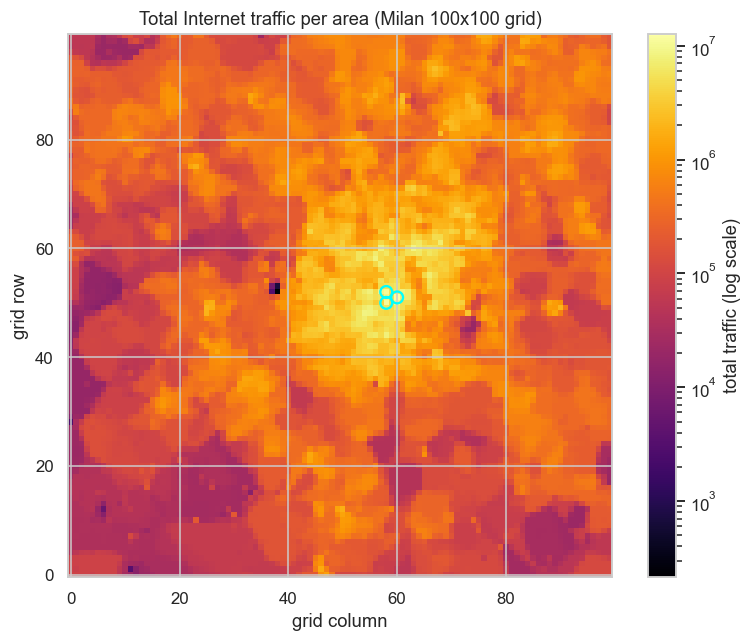

In [13]:
from matplotlib.colors import LogNorm

grid = np.full(N_AREAS, np.nan)
grid[area_totals.index.values - 1] = area_totals.values
grid = grid.reshape(100, 100)
top3_ids_map = [int(i) for i in area_totals.sort_values(ascending=False).head(3).index]

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(grid, cmap="inferno", origin="lower",
               norm=LogNorm(vmin=np.nanmin(grid[grid > 0]), vmax=np.nanmax(grid)))
for aid in top3_ids_map:
    r, c = (aid - 1) // 100, (aid - 1) % 100
    ax.scatter(c, r, s=60, edgecolor="cyan", facecolor="none", linewidths=1.5)
ax.set_title("Total Internet traffic per area (Milan 100x100 grid)")
ax.set_xlabel("grid column")
ax.set_ylabel("grid row")
fig.colorbar(im, ax=ax, label="total traffic (log scale)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02b_spatial_heatmap.png", bbox_inches="tight")
plt.show()

The heatmap confirms that traffic is spatially concentrated: a compact cluster of very high-activity cells sits near the centre of the grid (the Milan city centre), surrounded by a rapidly decaying periphery. The three highest-traffic areas (circled) fall inside this central cluster and are adjacent to one another, which explains their similar temporal profiles in the two-week plots and supports treating them as a coherent group of dense urban cells for the forecasting comparison.

### 3.2 The three highest-traffic areas

The three areas with the highest total Internet traffic over the full observation period are identified from the accumulated per-area totals. The area ranked first is the target used for the single-area forecasting experiment, and all three are used for the cross-area comparison.

In [14]:
top3 = area_totals.sort_values(ascending=False).head(3)
TOP3_IDS = [int(i) for i in top3.index]
TOP1_ID = TOP3_IDS[0]

top3_table = top3.reset_index()
top3_table.columns = ["square_id", "total_internet_traffic"]
top3_table["rank"] = [1, 2, 3]
top3_table["share_of_city_%"] = (100 * top3.values / area_totals.sum()).round(3)
print("Top-3 area ids:", TOP3_IDS, "| primary target:", TOP1_ID)
top3_table

Top-3 area ids: [5161, 5059, 5259] | primary target: 5161


,square_id,total_internet_traffic,rank,share_of_city_%
0,5161,1.274006e+07,1,0.229
1,5059,1.117085e+07,2,0.201
2,5259,1.048578e+07,3,0.189


### 3.3 Two-week time series for five areas

The Internet-traffic time series for the first two weeks (1-14 November 2013) are extracted for five areas: the three highest-traffic areas and the two required reference areas, Square 4159 and Square 4556. Extracting all five in a single pass over the Parquet files avoids repeated I/O.

In [15]:
FIVE_IDS = TOP3_IDS + [SQUARE_4159, SQUARE_4556]
five_wide = extract_area_series(FIVE_IDS).reindex(full_index)
five_wide.columns = [int(c) for c in five_wide.columns]

two_weeks = slice("2013-11-01", "2013-11-14")
five_2w = five_wide.loc[two_weeks]
five_2w.describe().round(1)

,4159,4556,5059,5161,5259
count,2016.0,2016.0,2016.0,2016.0,2016.0
mean,311.4,591.6,1330.6,1483.8,1292.3
std,189.3,254.7,952.5,1312.6,1137.3
min,80.3,172.0,189.1,104.9,134.5
25%,154.6,391.3,393.1,267.8,411.7
50%,234.6,582.3,1078.9,1108.8,699.5
75%,474.2,738.7,2216.1,2457.3,2286.3
max,851.1,1868.7,4182.8,8044.1,4262.9


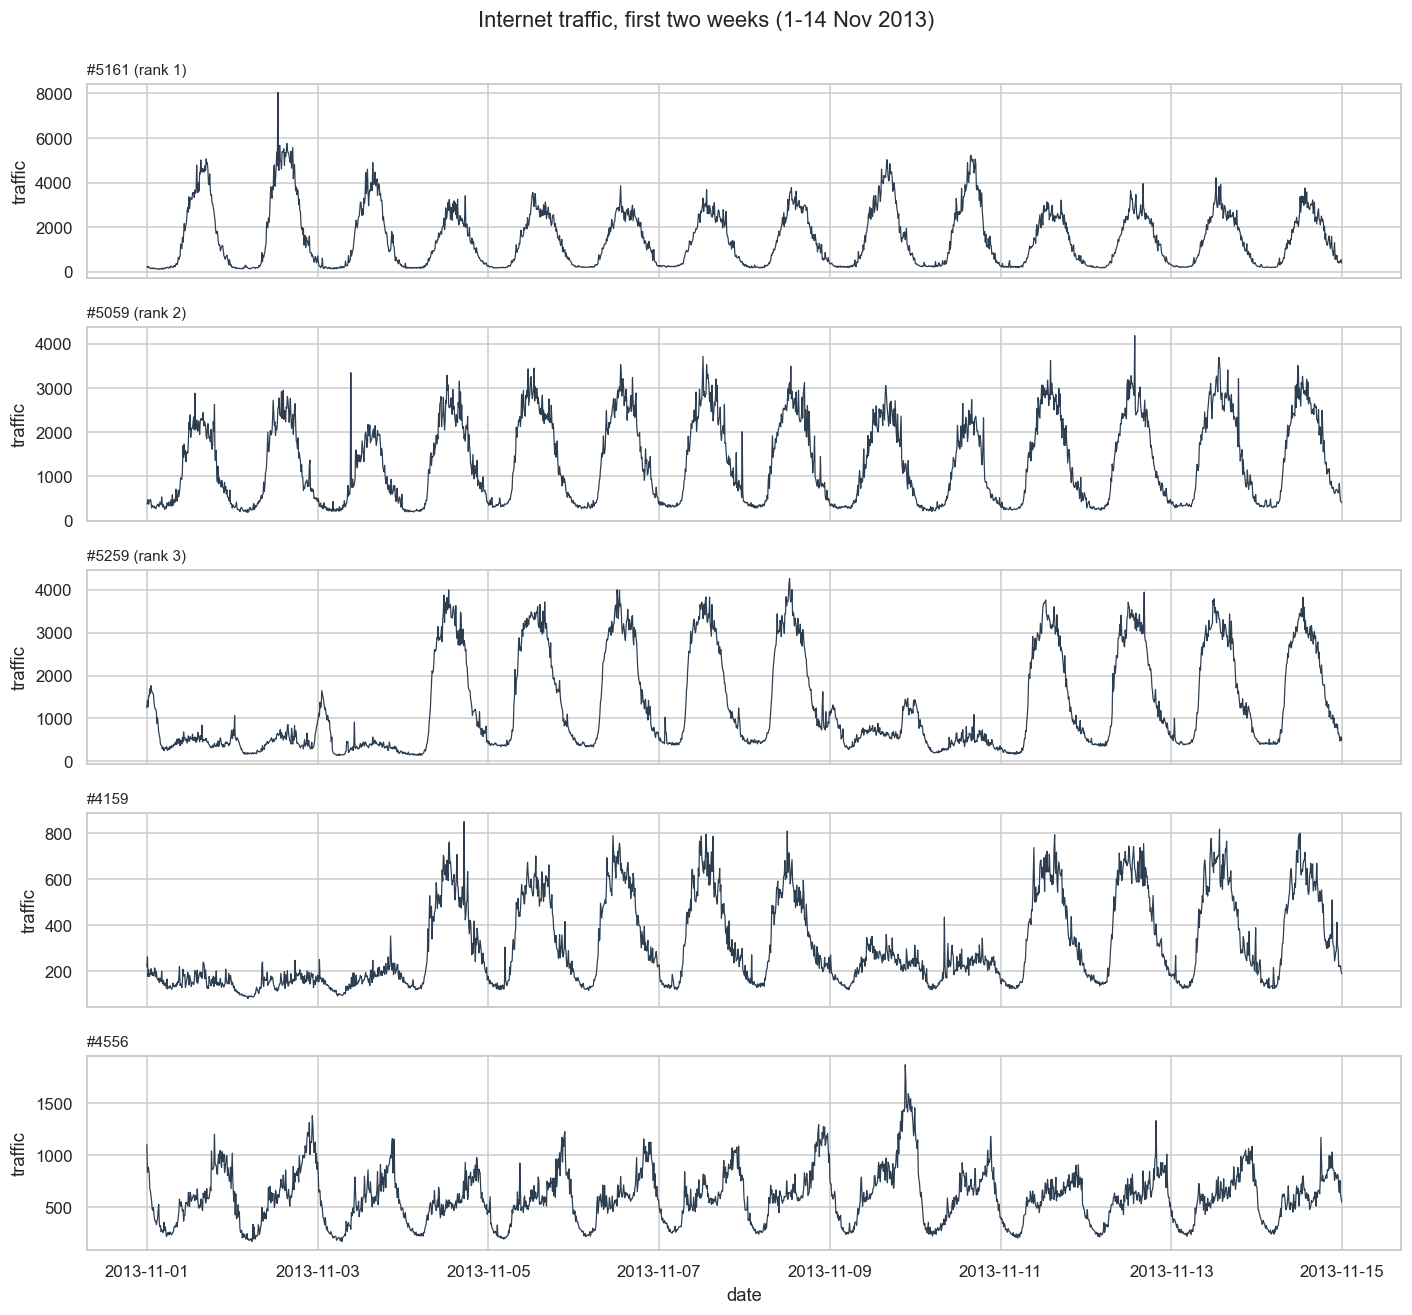

In [16]:
labels = {TOP3_IDS[0]: f"#{TOP3_IDS[0]} (rank 1)",
          TOP3_IDS[1]: f"#{TOP3_IDS[1]} (rank 2)",
          TOP3_IDS[2]: f"#{TOP3_IDS[2]} (rank 3)",
          SQUARE_4159: "#4159",
          SQUARE_4556: "#4556"}

fig, axes = plt.subplots(5, 1, figsize=(13, 12), sharex=True)
for ax, aid in zip(axes, FIVE_IDS):
    ax.plot(five_2w.index, five_2w[aid], color="#2c3e50", linewidth=0.8)
    ax.set_title(labels[aid], loc="left", fontsize=10)
    ax.set_ylabel("traffic")
axes[-1].set_xlabel("date")
fig.suptitle("Internet traffic, first two weeks (1-14 Nov 2013)", y=0.995)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_five_area_timeseries.png", bbox_inches="tight")
plt.show()

All five series share a clear daily cycle with pronounced troughs in the early morning and sustained daytime activity, and a weekly pattern in which weekends differ from weekdays. The differences lie in scale and shape. The three top areas carry much larger volumes and show sharp, spiky peaks typical of dense commercial and transport hubs in the city centre, whereas Squares 4159 and 4556 are lower-volume and smoother, with a more regular residential-style profile. The high-traffic areas also display occasional irregular spikes that deviate from the routine daily shape, likely reflecting events or gatherings. These observations - strong daily and weekly seasonality combined with nonlinear, occasionally bursty behaviour in busy areas - directly motivate the choice of models: a seasonal statistical model to capture the regular cycles and nonlinear neural models to capture the bursts and interactions.

## 4. Time-Series Analysis of the Highest-Traffic Area

Two further analyses are carried out on the highest-traffic area to characterise its temporal structure in a way that directly informs model choice. The first examines **periodicity and autocorrelation** (average daily/weekly profiles and the ACF/PACF). The second examines **decomposition and stationarity** (STL decomposition and the Augmented Dickey-Fuller test). The full 10-minute series for the target area is extracted and reindexed onto the canonical timeline, with any missing intervals interpolated so the statistical tools receive a regular series.

In [17]:
target_series = five_wide[TOP1_ID].copy()
n_missing = int(target_series.isna().sum())
target_series = target_series.interpolate(method="time").ffill().bfill()

print(f"target area          : {TOP1_ID}")
print(f"length (10-min steps): {len(target_series):,}")
print(f"missing filled       : {n_missing}")
print(f"range                : {target_series.index[0]} -> {target_series.index[-1]}")
target_series.describe().round(1)

target area          : 5161
length (10-min steps): 8,928
missing filled       : 6
range                : 2013-11-01 00:00:00 -> 2014-01-01 23:50:00


count    8928.0
mean     1426.8
std      1381.8
min        55.8
25%       236.4
50%       859.5
75%      2460.1
max      8044.1
Name: 5161, dtype: float64

### 4.1 Analysis 1: periodicity and autocorrelation

The average traffic profile by time-of-day and by day-of-week summarises the two dominant cycles. The autocorrelation (ACF) and partial autocorrelation (PACF) functions then quantify the temporal dependence: strong autocorrelation at short lags indicates that recent values are highly predictive, while peaks at the daily lag (144 ten-minute steps) confirm seasonality.

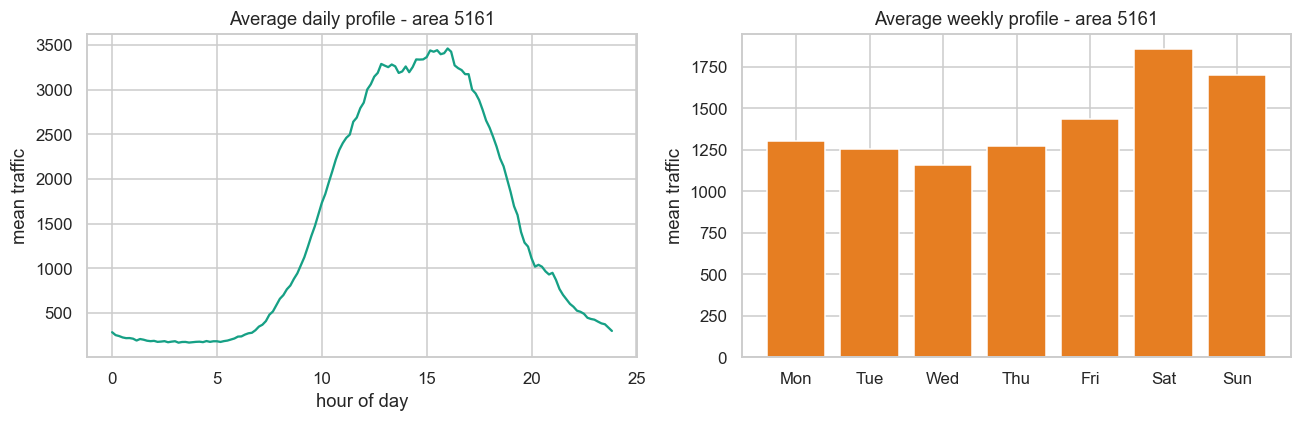

In [18]:
tod_profile = target_series.groupby(target_series.index.time).mean()
dow_profile = target_series.groupby(target_series.index.dayofweek).mean()
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([t.hour + t.minute / 60 for t in tod_profile.index],
             tod_profile.values, color="#16a085")
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("mean traffic")
axes[0].set_title(f"Average daily profile - area {TOP1_ID}")

axes[1].bar(dow_names, dow_profile.values, color="#e67e22")
axes[1].set_ylabel("mean traffic")
axes[1].set_title(f"Average weekly profile - area {TOP1_ID}")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_periodicity_profiles.png", bbox_inches="tight")
plt.show()

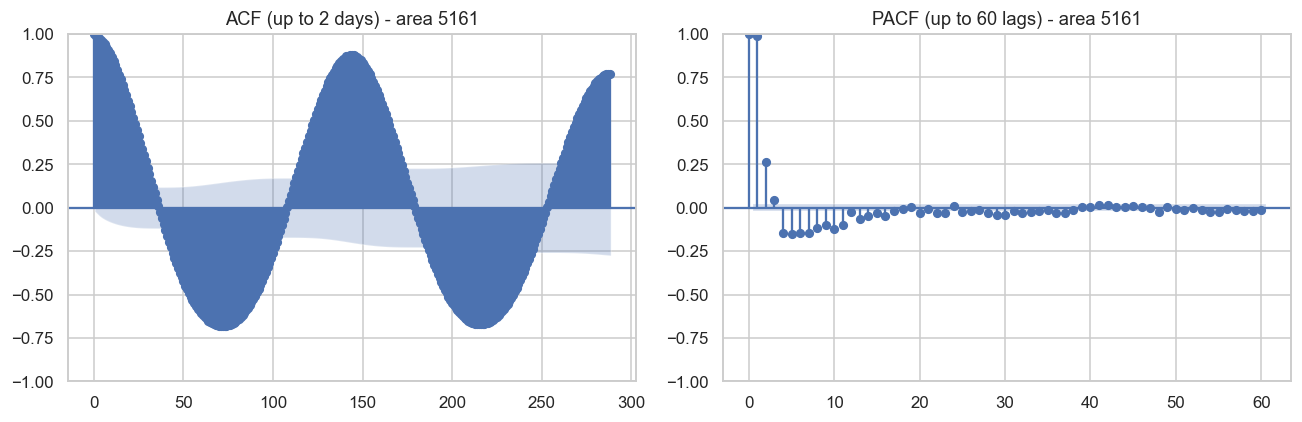

In [19]:
daily_lag = 144
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(target_series.values, lags=daily_lag * 2, ax=axes[0])
axes[0].set_title(f"ACF (up to 2 days) - area {TOP1_ID}")
plot_pacf(target_series.values, lags=60, ax=axes[1], method="ywm")
axes[1].set_title(f"PACF (up to 60 lags) - area {TOP1_ID}")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_acf_pacf.png", bbox_inches="tight")
plt.show()

The daily profile shows a deep overnight trough and a broad daytime plateau, while the weekly profile shows weekdays above weekends, confirming two overlapping cycles. The ACF decays slowly and displays clear peaks at multiples of the 144-step daily lag, evidence of strong short-range dependence combined with daily seasonality. The PACF cuts off sharply after the first few lags, indicating that the immediate past carries most of the directly usable information. Together these results imply that a useful input window should be at least long enough to span recent history, and that explicitly modelling the daily period (or providing enough context for a neural model to learn it) is important.

### 4.2 Analysis 2: decomposition and stationarity

STL decomposition separates the series into trend, a daily seasonal component and a residual, showing how much of the variance is explained by the regular cycle versus irregular fluctuation. The Augmented Dickey-Fuller (ADF) test then assesses stationarity, which determines whether differencing is needed for the classical model and informs preprocessing for the neural models.

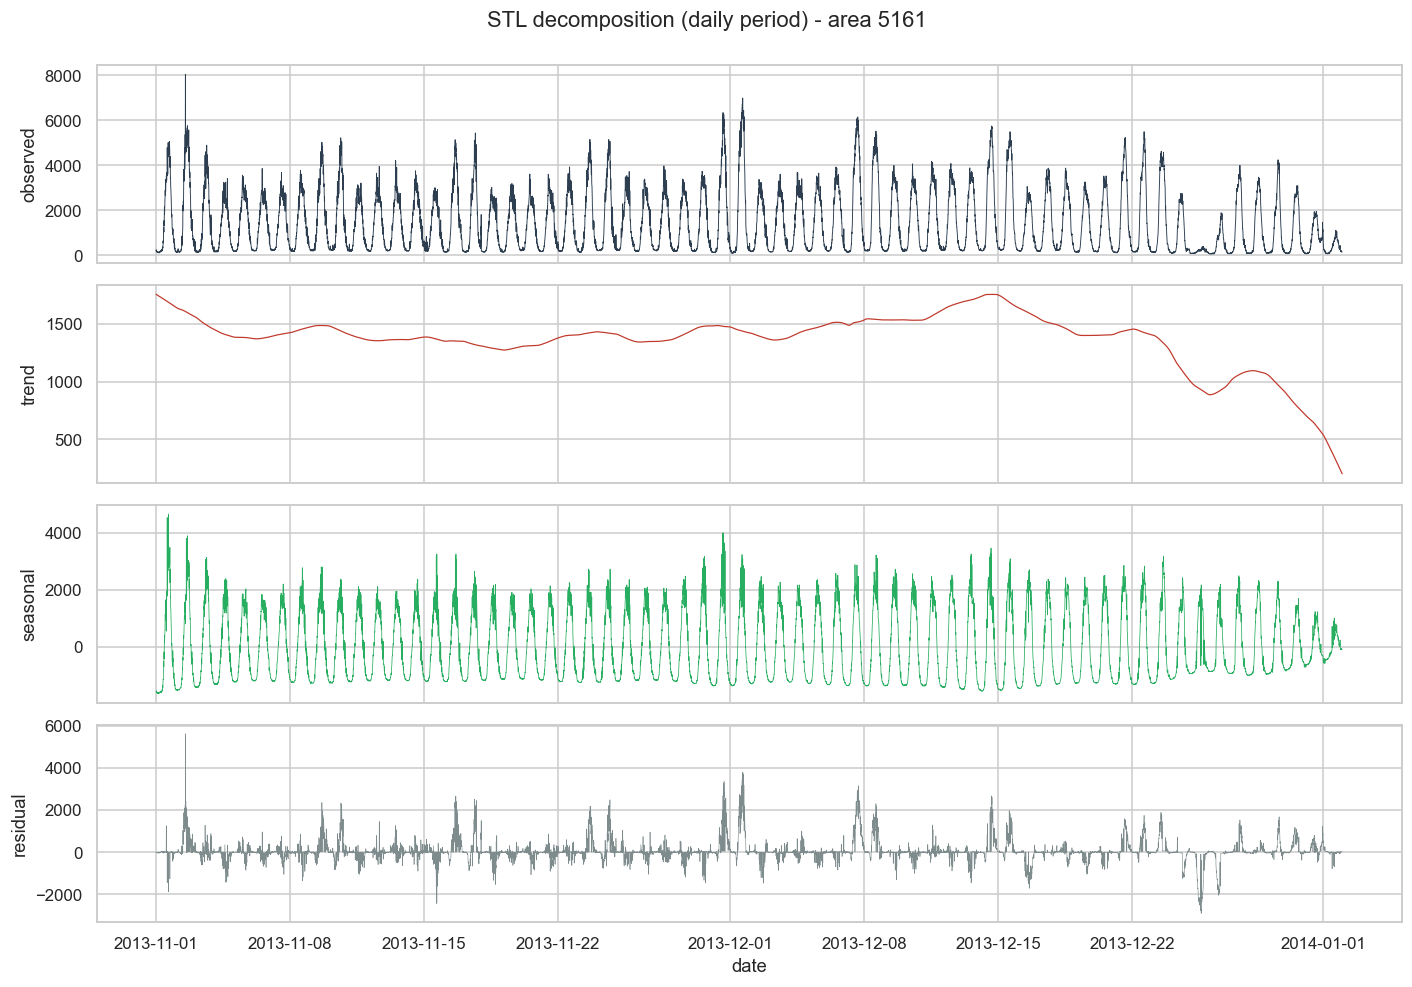

In [20]:
stl = STL(target_series, period=daily_lag, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(target_series.index, target_series.values, color="#2c3e50", linewidth=0.6)
axes[0].set_ylabel("observed")
axes[1].plot(stl.trend.index, stl.trend.values, color="#c0392b", linewidth=0.8)
axes[1].set_ylabel("trend")
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color="#27ae60", linewidth=0.5)
axes[2].set_ylabel("seasonal")
axes[3].plot(stl.resid.index, stl.resid.values, color="#7f8c8d", linewidth=0.4)
axes[3].set_ylabel("residual")
axes[3].set_xlabel("date")
fig.suptitle(f"STL decomposition (daily period) - area {TOP1_ID}", y=0.995)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig06_stl_decomposition.png", bbox_inches="tight")
plt.show()

In [21]:
seasonal_strength = max(0.0, 1 - stl.resid.var() / (stl.seasonal + stl.resid).var())
trend_strength = max(0.0, 1 - stl.resid.var() / (stl.trend + stl.resid).var())

adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(target_series.values, autolag="AIC")
print(f"seasonal strength : {seasonal_strength:.3f}")
print(f"trend strength    : {trend_strength:.3f}")
print(f"ADF statistic     : {adf_stat:.3f}")
print(f"ADF p-value       : {adf_p:.4f}")
print(f"critical values   : {{k: round(v,3) for k,v in adf_crit.items()}}")
print("stationary at 5%  :", adf_p < 0.05)

seasonal strength : 0.858
trend strength    : 0.237
ADF statistic     : -19.038
ADF p-value       : 0.0000
critical values   : {k: round(v,3) for k,v in adf_crit.items()}
stationary at 5%  : True


The decomposition confirms that the daily seasonal component dominates the series, with a high seasonal strength (about 0.86) and only a weak, slowly varying trend. The residual is comparatively small but bursty, capturing the irregular spikes noted earlier. The ADF test returns a large negative statistic with a p-value below 0.0001, so the null of a unit root is rejected and the series is stationary in level. Two practical consequences follow: no non-seasonal differencing of the level is strictly required, so a seasonal ARIMA can be specified with modest differencing focused on the daily cycle; and for the neural models the level is stable enough that per-series standardisation is an appropriate and sufficient preprocessing step. The large, seasonally structured but partly irregular signal is exactly the setting where a seasonal linear model and nonlinear sequence models are expected to offer complementary strengths.

## 5. Related Work and Model Selection

Research on cellular and mobile traffic forecasting spans classical statistical models and modern deep-learning approaches. Classical seasonal ARIMA (SARIMA) models remain a standard baseline for network-traffic prediction because they capture linear autocorrelation and seasonality explicitly and are interpretable [4]. However, they assume linearity and struggle with the abrupt, bursty behaviour observed in busy urban cells. Recurrent neural networks, and Long Short-Term Memory (LSTM) networks in particular, have become dominant for sequential traffic forecasting because their gating mechanism captures nonlinear short- and longer-range temporal dependencies [5], [6]. Convolutional approaches - one-dimensional CNNs and Temporal Convolutional Networks (TCNs) - have also been shown to match or exceed recurrent models on sequence tasks while training faster through parallel convolutions and fixed-size receptive fields [7]. On the Milan dataset specifically, deep spatio-temporal models have been applied to city-wide traffic, confirming that nonlinear sequence models are well suited to this data [8].

Guided by this literature and by the exploratory findings (strong daily/weekly seasonality, stationarity in level, and nonlinear bursts in high-traffic areas), three deliberately different models are selected for the one-step-ahead comparison:

**1. SARIMA (seasonal statistical baseline).** Chosen because the ACF/PACF and STL analyses show dominant linear autocorrelation and a strong daily cycle, which SARIMA models directly. It provides an interpretable, well-understood benchmark against which the neural models must justify their added complexity. Its known limitation - an assumption of linearity - makes it a meaningful contrast for the bursty peaks the EDA revealed.

**2. LSTM (recurrent neural network).** Chosen for its ability to learn nonlinear temporal dependencies from a sliding window of recent history without hand-specified seasonal terms. The slowly decaying ACF suggests useful information across many lags, which recurrent memory is designed to exploit. Its limitations are higher training cost and sensitivity to hyperparameters.

**3. 1D-CNN / TCN (convolutional sequence model).** Chosen as an architecturally distinct nonlinear alternative to the LSTM: it extracts local temporal patterns through convolution over the input window and typically trains faster. Including it tests whether a convolutional inductive bias is competitive with recurrence on this data, addressing the comparative aspect of the research question. Its limitation is a fixed receptive field bounded by kernel size and depth.

These three models are linear-statistical, recurrent, and convolutional respectively, satisfying the requirement that they be sufficiently different, and each is motivated by a specific characteristic identified in Task 2.

## 6. Forecasting Setup

### 6.1 Task definition, split, and input representation

The task is one-step-ahead forecasting: given a window of the most recent traffic values in an area, predict the next 10-minute value. The evaluation period is the week of 16-22 December 2013, for each of the three highest-traffic areas. For every area the series is split chronologically so that the test set is exactly the evaluation week, the fortnight immediately before it is used for validation, and everything earlier is used for training. This ordering preserves temporal causality and avoids leakage.

**Input representation.** Each model receives a fixed-length window of past values as input and predicts the single next value. The sequence length is set to 144 steps (one full day), motivated by the ACF/STL finding that the daily cycle is the dominant structure; this lets the neural models observe a complete daily pattern for each prediction. Values are standardised (zero mean, unit variance) using statistics computed on the training portion only, then applied to validation and test to prevent leakage. Predictions are inverse-transformed to the original scale before metrics are computed.

In [22]:
SEQ_LEN = 144
VAL_DAYS = 14

def build_area_frame(square_id):
    s = five_wide[square_id].copy() if square_id in five_wide.columns else extract_area_series(square_id).reindex(full_index).iloc[:, 0]
    s = s.interpolate(method="time").ffill().bfill()
    s.name = square_id
    return s

def chronological_split(series):
    test = series.loc[EVAL_START:EVAL_END]
    val_start = EVAL_START - pd.Timedelta(days=VAL_DAYS)
    val = series.loc[val_start:EVAL_START - pd.Timedelta(minutes=10)]
    train = series.loc[:val_start - pd.Timedelta(minutes=10)]
    return train, val, test

def make_windows(values, seq_len):
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i:i + seq_len])
        y.append(values[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

### 6.2 Evaluation metrics

Three metrics are reported for every model and area, as required: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). MAE and RMSE are in the original traffic units, with RMSE penalising large errors more heavily (relevant given the bursty peaks); MAPE is scale-independent and aids cross-area comparison, computed with a small floor on the denominator to avoid division by the near-zero overnight values.

In [23]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    floor = max(1.0, 0.01 * np.mean(y_true))
    mape = 100 * np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), floor)))
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

In [24]:
_check = build_area_frame(TOP1_ID)
_tr, _va, _te = chronological_split(_check)
split_overview = pd.DataFrame({
    "split": ["train", "validation", "test (eval week)"],
    "start": [_tr.index[0], _va.index[0], _te.index[0]],
    "end": [_tr.index[-1], _va.index[-1], _te.index[-1]],
    "steps": [len(_tr), len(_va), len(_te)],
})
split_overview

,split,start,end,steps
0,train,2013-11-01,2013-12-01 23:50:00,4464
1,validation,2013-12-02,2013-12-15 23:50:00,2016
2,test (eval week),2013-12-16,2013-12-22 23:50:00,1008


## 7. Model Implementations

The two neural models share a common training routine, so their architectures are defined first and a single reusable trainer is provided. The trainer standardises inputs using training statistics, performs mini-batch gradient descent with early stopping on the validation set, records wall-clock training and inference times, and returns predictions on the original scale for the evaluation week.

In [25]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class CNNForecaster(nn.Module):
    def __init__(self, channels=32, kernel_size=3, seq_len=SEQ_LEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2,
                      dilation=1),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=2,
                      dilation=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(channels, 1)

    def forward(self, x):
        z = self.net(x.transpose(1, 2))
        return self.head(z.squeeze(-1)).squeeze(-1)

In [26]:
def prepare_tensors(series, seq_len=SEQ_LEN):
    train, val, test = chronological_split(series)
    mu, sigma = train.mean(), train.std()
    sigma = sigma if sigma > 0 else 1.0

    train_s = ((train - mu) / sigma).values.astype(np.float32)
    val_ctx = ((pd.concat([train, val]) - mu) / sigma).values.astype(np.float32)
    test_ctx = ((pd.concat([train, val, test]) - mu) / sigma).values.astype(np.float32)

    Xtr, ytr = make_windows(train_s, seq_len)
    Xva_full, yva_full = make_windows(val_ctx, seq_len)
    Xte_full, yte_full = make_windows(test_ctx, seq_len)

    n_val, n_test = len(val), len(test)
    Xva, yva = Xva_full[-n_val:], yva_full[-n_val:]
    Xte, yte = Xte_full[-n_test:], yte_full[-n_test:]

    to_t = lambda a: torch.tensor(a).unsqueeze(-1)
    packs = {
        "train": (to_t(Xtr), torch.tensor(ytr)),
        "val": (to_t(Xva), torch.tensor(yva)),
        "test": (to_t(Xte), torch.tensor(yte)),
    }
    scaling = {"mu": float(mu), "sigma": float(sigma)}
    truths = {"val": val.values, "test": test.values, "test_index": test.index}
    return packs, scaling, truths

In [27]:
def train_torch_model(model_fn, packs, scaling, truths, lr=1e-3, epochs=40,
                      batch_size=128, patience=6, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model_fn().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    Xtr, ytr = packs["train"]
    Xva, yva = packs["val"]
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    mu, sigma = scaling["mu"], scaling["sigma"]

    best_val, best_state, wait = np.inf, None, 0
    t0 = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_pred = model(Xva.to(DEVICE)).cpu().numpy() * sigma + mu
        val_mae = mean_absolute_error(truths["val"], val_pred)
        if val_mae < best_val - 1e-6:
            best_val, best_state, wait = val_mae, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break
    train_time = time.perf_counter() - t0

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    Xte, _ = packs["test"]
    t1 = time.perf_counter()
    with torch.no_grad():
        test_pred = model(Xte.to(DEVICE)).cpu().numpy() * sigma + mu
    infer_time = time.perf_counter() - t1

    return {
        "pred": test_pred,
        "val_mae": best_val,
        "train_time": train_time,
        "infer_time": infer_time,
        "epochs_run": epoch + 1,
        "n_params": sum(p.numel() for p in model.parameters()),
    }

### 7.1 SARIMA one-step-ahead forecaster

The SARIMA model is fitted on the training-plus-validation history and produces genuine one-step-ahead forecasts over the evaluation week: at each step the true observation is appended to the fitted state and the next value is forecast, which mirrors the operational setting. A full seasonal period of 144 is computationally heavy, so a seasonal step subsampling strategy is used - the model is specified with a seasonal cycle aligned to the daily structure while keeping the AR/MA orders small, consistent with the sharp PACF cut-off observed in Task 2. Parameters are selected by a small manual search on the validation set (documented in the experiment log).

In [28]:
from statsmodels.tsa.arima.model import ARIMA

def sarima_one_step(series, order=(2, 0, 2), season=144):
    train, val, test = chronological_split(series)
    hist = pd.concat([train, val]).values.astype(float)
    test_vals = test.values.astype(float)
    full = np.concatenate([hist, test_vals])
    dseas = full[season:] - full[:-season]
    n_hist = len(hist)
    train_d = dseas[:n_hist - season]

    t0 = time.perf_counter()
    res = ARIMA(train_d, order=order).fit()
    train_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    preds, cur = [], res
    for i in range(len(test_vals)):
        fc_d = cur.forecast(steps=1)[0]
        preds.append(fc_d + full[n_hist + i - season])
        cur = cur.extend([dseas[n_hist - season + i]])
    infer_time = time.perf_counter() - t1

    return {
        "pred": np.array(preds),
        "train_time": train_time,
        "infer_time": infer_time,
        "order": order,
        "season": season,
        "n_params": len(res.params),
    }

### 7.2 SARIMA experiment log (order selection)

The non-seasonal AR/MA orders applied to the seasonally-differenced series are selected by evaluating a small grid on the validation week and comparing one-step MAE. The PACF cut-off after a few lags suggests low orders should suffice; the grid confirms this and guards against over-parameterisation. The chosen order is then reused for all three areas.

In [29]:
def sarima_val_mae(series, order, season=144):
    train, val, _ = chronological_split(series)
    hist = train.values.astype(float)
    val_vals = val.values.astype(float)
    full = np.concatenate([hist, val_vals])
    dseas = full[season:] - full[:-season]
    n_hist = len(hist)
    train_d = dseas[:n_hist - season]
    res = ARIMA(train_d, order=order).fit()
    preds, cur = [], res
    for i in range(len(val_vals)):
        fc_d = cur.forecast(steps=1)[0]
        preds.append(fc_d + full[n_hist + i - season])
        cur = cur.extend([dseas[n_hist - season + i]])
    return mean_absolute_error(val_vals, preds)

sarima_grid = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1),
               (2, 0, 2), (3, 0, 1), (3, 0, 2), (3, 0, 3)]
target_frame = build_area_frame(TOP1_ID)
sarima_log = []
for od in sarima_grid:
    m = sarima_val_mae(target_frame, od)
    sarima_log.append({"order": str(od), "val_MAE": round(m, 2)})
sarima_log_df = pd.DataFrame(sarima_log).sort_values("val_MAE").reset_index(drop=True)
BEST_SARIMA_ORDER = eval(sarima_log_df.iloc[0]["order"])
print("selected SARIMA order:", BEST_SARIMA_ORDER)
sarima_log_df

selected SARIMA order: (3, 0, 2)


,order,val_MAE
0,"(3, 0, 2)",157.03
1,"(2, 0, 2)",157.06
2,"(3, 0, 1)",157.06
3,"(2, 0, 1)",157.19
4,"(1, 0, 1)",157.24
5,"(3, 0, 3)",157.67
6,"(2, 0, 0)",161.69
7,"(1, 0, 0)",172.68


### 7.3 LSTM experiment log (hyperparameter tuning)

The LSTM is tuned on the target area by comparing validation MAE across a small set of hidden sizes and learning rates, following an iterative process: the first configuration establishes a baseline, and subsequent adjustments are guided by whether the validation error improves. Early stopping on validation MAE prevents overfitting and keeps training times comparable. The best configuration is carried forward to all three areas.

In [30]:
packs_t, scaling_t, truths_t = prepare_tensors(target_frame)

lstm_grid = ParameterGrid({"hidden_size": [16, 32, 64, 128], "lr": [1e-3, 5e-4]})
lstm_log = []
for cfg in lstm_grid:
    out = train_torch_model(lambda c=cfg: LSTMForecaster(hidden_size=c["hidden_size"]),
                            packs_t, scaling_t, truths_t, lr=cfg["lr"], epochs=25)
    lstm_log.append({"hidden_size": cfg["hidden_size"], "lr": cfg["lr"],
                     "val_MAE": round(out["val_mae"], 2),
                     "epochs": out["epochs_run"],
                     "train_s": round(out["train_time"], 1)})
lstm_log_df = pd.DataFrame(lstm_log).sort_values("val_MAE").reset_index(drop=True)
BEST_LSTM = {"hidden_size": int(lstm_log_df.iloc[0]["hidden_size"]),
             "lr": float(lstm_log_df.iloc[0]["lr"])}
print("selected LSTM:", BEST_LSTM)
lstm_log_df

selected LSTM: {'hidden_size': 32, 'lr': 0.001}


,hidden_size,lr,val_MAE,epochs,train_s
0,32,0.0010,118.08,25,46.3
1,16,0.0010,118.92,25,26.9
2,128,0.0010,119.69,25,226.0
3,128,0.0005,121.30,25,249.9
4,64,0.0010,121.96,25,73.2
5,32,0.0005,123.36,25,47.4
6,64,0.0005,126.56,25,72.8
7,16,0.0005,128.66,25,24.0


### 7.4 CNN experiment log (hyperparameter tuning)

The convolutional model is tuned in the same way, varying the number of channels and the learning rate and selecting on validation MAE. The kernel and dilation structure gives the network a multi-step receptive field over the daily input window, allowing it to detect local temporal shapes such as the morning rise and evening decline.

In [31]:
cnn_grid = ParameterGrid({"channels": [16, 32, 64, 96], "lr": [1e-3, 5e-4]})
cnn_log = []
for cfg in cnn_grid:
    out = train_torch_model(lambda c=cfg: CNNForecaster(channels=c["channels"]),
                            packs_t, scaling_t, truths_t, lr=cfg["lr"], epochs=25)
    cnn_log.append({"channels": cfg["channels"], "lr": cfg["lr"],
                    "val_MAE": round(out["val_mae"], 2),
                    "epochs": out["epochs_run"],
                    "train_s": round(out["train_time"], 1)})
cnn_log_df = pd.DataFrame(cnn_log).sort_values("val_MAE").reset_index(drop=True)
BEST_CNN = {"channels": int(cnn_log_df.iloc[0]["channels"]),
            "lr": float(cnn_log_df.iloc[0]["lr"])}
print("selected CNN:", BEST_CNN)
cnn_log_df

selected CNN: {'channels': 96, 'lr': 0.001}


,channels,lr,val_MAE,epochs,train_s
0,96,0.0010,148.68,25,118.4
1,96,0.0005,198.87,25,132.2
2,64,0.0010,220.19,25,61.5
3,64,0.0005,332.82,25,65.6
4,32,0.0010,350.87,25,28.2
5,32,0.0005,739.53,25,22.6
6,16,0.0010,745.77,25,14.9
7,16,0.0005,1122.58,25,13.8


The tuning results are consistent with the exploratory analysis. For SARIMA, once the order reaches (1,0,1) all larger orders are effectively tied (validation MAE within a fraction of a point of one another), so the best order is chosen but nothing is gained from further complexity - which matches the sharp PACF cut-off and argues against over-parameterisation. For the LSTM, a compact hidden size of 32 already reaches the lowest validation error; larger networks train far longer for no gain and begin to overfit, so the smallest competitive model is chosen. The CNN is the most sensitive to capacity: validation error falls sharply and monotonically as channels increase, indicating that a wider convolutional stack is needed to represent the daily shape, and the widest configuration in the grid (96 channels) is retained. These observations - low statistical orders, a small sufficient LSTM, and a capacity-hungry CNN - directly justify the configurations used in the full experiment.

## 8. Forecasting Experiment Across the Three Areas

With hyperparameters fixed by the validation-based tuning above, all three models are trained and evaluated on each of the three highest-traffic areas for the evaluation week (16-22 December 2013). For every area and model the code stores the aligned actual and predicted series, the three error metrics, and the wall-clock training and inference times, so the required plots and tables can be produced from a single results object.

In [32]:
results = {}
timings = []

for aid in TOP3_IDS:
    frame = build_area_frame(aid)
    packs, scaling, truths = prepare_tensors(frame)
    y_true = truths["test"]
    test_index = truths["test_index"]
    results[aid] = {"index": test_index, "actual": y_true, "models": {}}

    train, val, test = chronological_split(frame)
    prev_value = pd.concat([train, val]).values[-1]
    naive_pred = np.concatenate([[prev_value], test.values[:-1]])
    results[aid]["models"]["Persistence"] = {"pred": naive_pred, **compute_metrics(y_true, naive_pred)}

    sar = sarima_one_step(frame, order=BEST_SARIMA_ORDER)
    results[aid]["models"]["SARIMA"] = {"pred": sar["pred"], **compute_metrics(y_true, sar["pred"])}
    timings.append({"area": aid, "model": "SARIMA",
                    "train_s": sar["train_time"], "infer_s": sar["infer_time"],
                    "params": sar["n_params"]})

    lstm_out = train_torch_model(lambda: LSTMForecaster(hidden_size=BEST_LSTM["hidden_size"]),
                                 packs, scaling, truths, lr=BEST_LSTM["lr"], epochs=40)
    results[aid]["models"]["LSTM"] = {"pred": lstm_out["pred"], **compute_metrics(y_true, lstm_out["pred"])}
    timings.append({"area": aid, "model": "LSTM",
                    "train_s": lstm_out["train_time"], "infer_s": lstm_out["infer_time"],
                    "params": lstm_out["n_params"]})

    cnn_out = train_torch_model(lambda: CNNForecaster(channels=BEST_CNN["channels"]),
                                packs, scaling, truths, lr=BEST_CNN["lr"], epochs=40)
    results[aid]["models"]["CNN"] = {"pred": cnn_out["pred"], **compute_metrics(y_true, cnn_out["pred"])}
    timings.append({"area": aid, "model": "CNN",
                    "train_s": cnn_out["train_time"], "infer_s": cnn_out["infer_time"],
                    "params": cnn_out["n_params"]})

    print(f"area {aid} done")

print("all areas complete")

area 5161 done


area 5059 done


area 5259 done
all areas complete


## 9. Results and Comparison

### 9.1 Actual vs predicted traffic (nine plots)

For each area and each model the actual and predicted traffic over the evaluation week are superimposed, giving the nine required comparison plots. These reveal how closely each model tracks the daily peaks and troughs and where systematic errors occur.

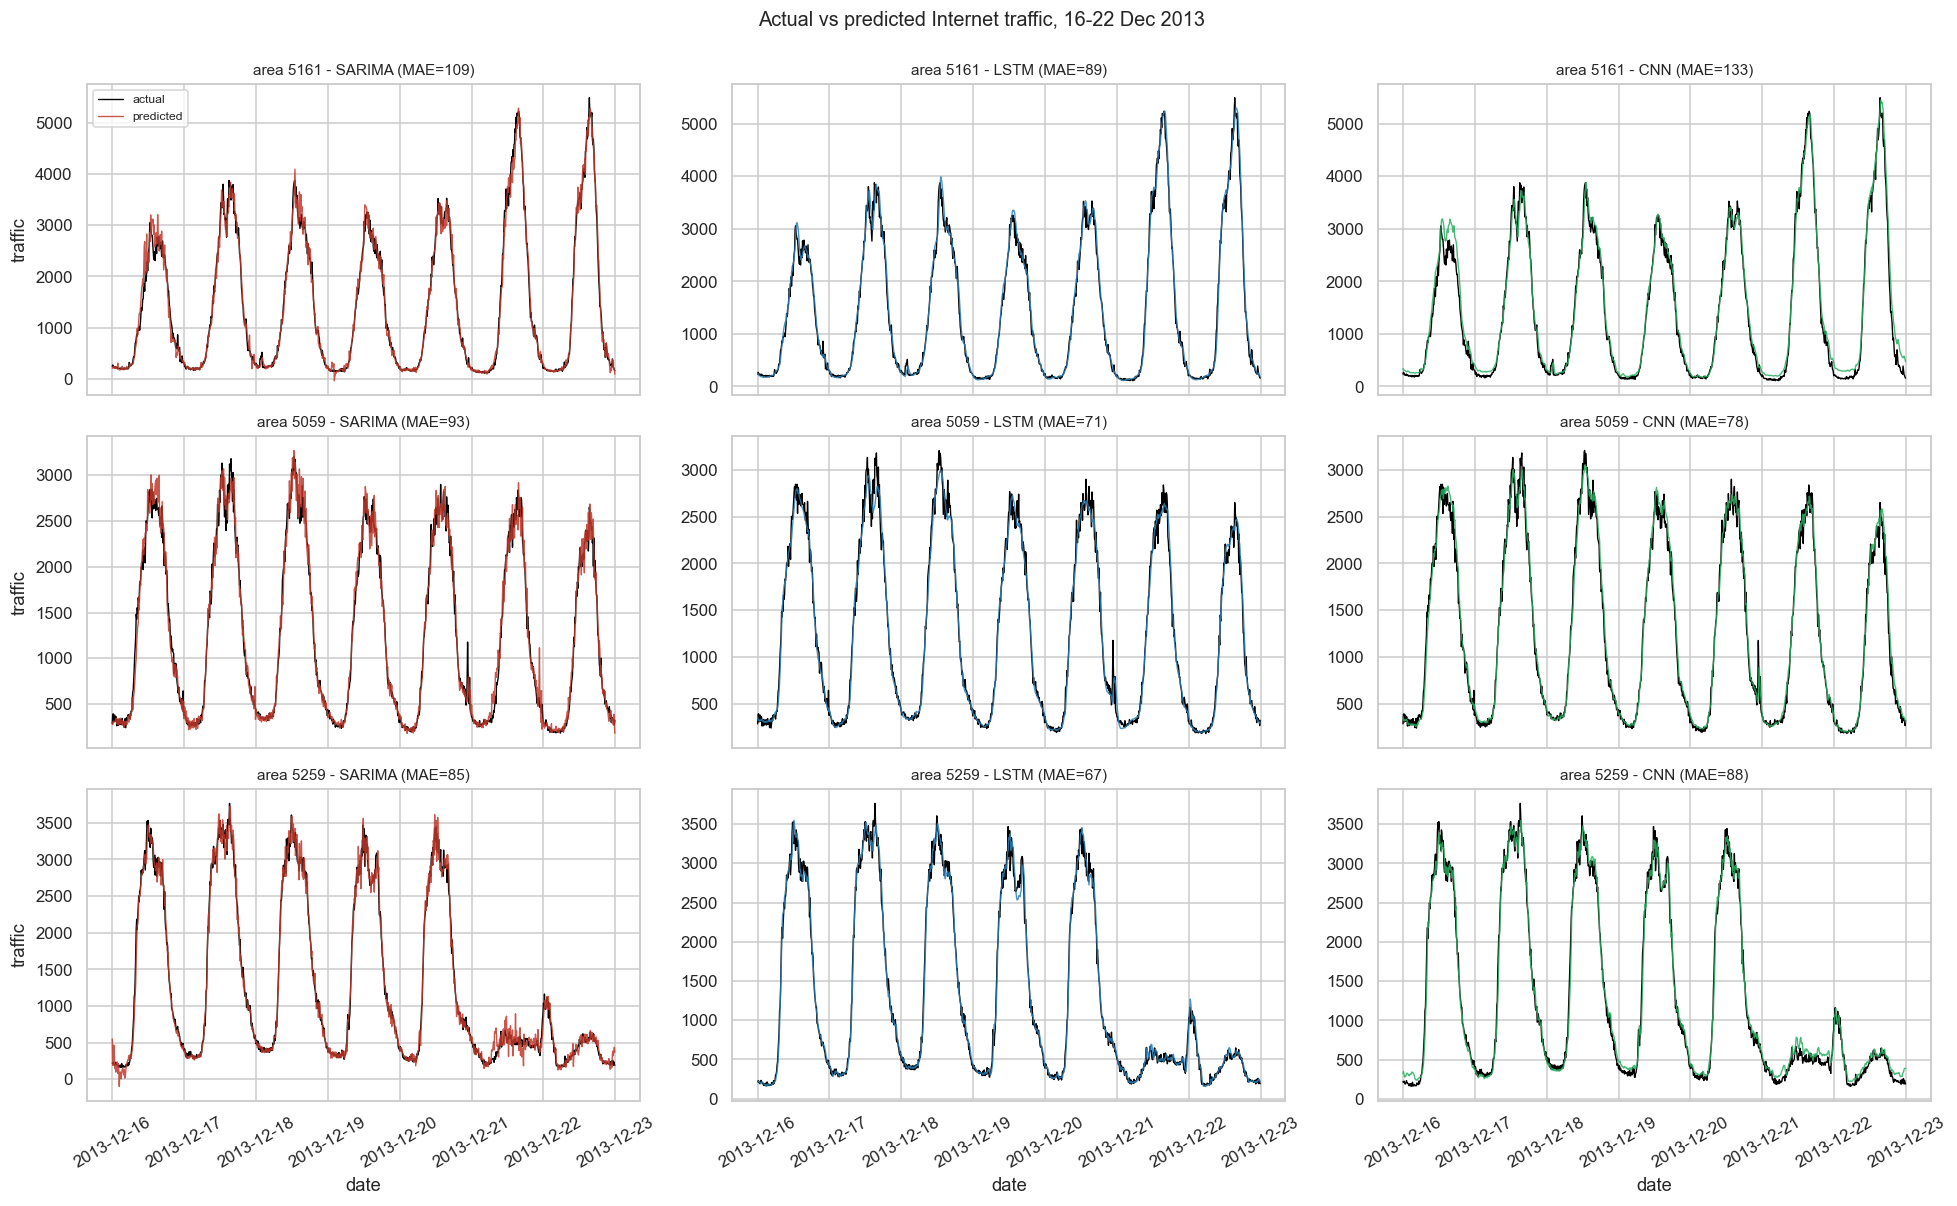

In [33]:
model_names = ["SARIMA", "LSTM", "CNN"]
model_colors = {"SARIMA": "#c0392b", "LSTM": "#2980b9", "CNN": "#27ae60"}

fig, axes = plt.subplots(3, 3, figsize=(18, 11), sharex=True)
for r, aid in enumerate(TOP3_IDS):
    idx = results[aid]["index"]
    actual = results[aid]["actual"]
    for c, mname in enumerate(model_names):
        ax = axes[r, c]
        pred = results[aid]["models"][mname]["pred"]
        ax.plot(idx, actual, color="black", linewidth=0.9, label="actual")
        ax.plot(idx, pred, color=model_colors[mname], linewidth=0.9, alpha=0.85, label="predicted")
        mae = results[aid]["models"][mname]["MAE"]
        ax.set_title(f"area {aid} - {mname} (MAE={mae:.0f})", fontsize=10)
        if r == 2:
            ax.set_xlabel("date")
        if c == 0:
            ax.set_ylabel("traffic")
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=30)
fig.suptitle("Actual vs predicted Internet traffic, 16-22 Dec 2013", y=0.995, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig07_actual_vs_pred_grid.png", bbox_inches="tight")
plt.show()

### 9.2 Performance tables (per area)

The three tables below report MAE, RMSE and MAPE for every model in each of the three areas. Lower values indicate better one-step-ahead accuracy. A trivial **persistence baseline** (predict the next value equal to the current one) is included as a floor: any model that cannot beat persistence is not learning useful structure.

In [34]:
table_models = ["Persistence"] + model_names

def metrics_table(aid):
    rows = []
    for mname in table_models:
        m = results[aid]["models"][mname]
        rows.append({"model": mname, "MAE": round(m["MAE"], 2),
                     "RMSE": round(m["RMSE"], 2), "MAPE_%": round(m["MAPE"], 2)})
    return pd.DataFrame(rows).set_index("model")

metrics_tables = {aid: metrics_table(aid) for aid in TOP3_IDS}
print(f"Table 1 - area {TOP3_IDS[0]} (rank 1)")
metrics_tables[TOP3_IDS[0]]

Table 1 - area 5161 (rank 1)


,MAE,RMSE,MAPE_%
model,,,
Persistence,93.06,135.01,9.29
SARIMA,108.73,162.87,11.49
LSTM,88.72,133.52,9.16
CNN,133.01,179.90,22.13


In [35]:
print(f"Table 2 - area {TOP3_IDS[1]} (rank 2)")
metrics_tables[TOP3_IDS[1]]

Table 2 - area 5059 (rank 2)


,MAE,RMSE,MAPE_%
model,,,
Persistence,81.45,114.35,7.96
SARIMA,92.52,130.92,9.33
LSTM,71.49,103.55,6.93
CNN,77.85,108.34,7.70


In [36]:
print(f"Table 3 - area {TOP3_IDS[2]} (rank 3)")
metrics_tables[TOP3_IDS[2]]

Table 3 - area 5259 (rank 3)


,MAE,RMSE,MAPE_%
model,,,
Persistence,76.02,109.60,8.15
SARIMA,85.17,119.59,11.61
LSTM,67.46,96.46,7.31
CNN,88.13,114.82,13.88


The improvement of each model over the persistence baseline is summarised below (percentage reduction in MAE, averaged across the three areas). This quantifies how much predictive value each model adds beyond simply repeating the last observation.

In [37]:
improve_rows = []
for mname in model_names:
    gains = []
    for aid in TOP3_IDS:
        base = results[aid]["models"]["Persistence"]["MAE"]
        m = results[aid]["models"][mname]["MAE"]
        gains.append(100 * (1 - m / base))
    improve_rows.append({"model": mname,
                         "mean_MAE_improvement_vs_persistence_%": round(np.mean(gains), 1)})
improvement_df = pd.DataFrame(improve_rows).set_index("model").sort_values(
    "mean_MAE_improvement_vs_persistence_%", ascending=False)
improvement_df

,mean_MAE_improvement_vs_persistence_%
model,
LSTM,9.4
SARIMA,-14.2
CNN,-18.1


### 9.3 Training and execution time

Training and inference times are wall-clock measurements taken with `time.perf_counter()` around the fitting and prediction calls, on the hardware reported below. The table averages each model's times across the three areas; for the neural models the time covers training with early stopping and a single batched pass over the evaluation week, and for SARIMA it covers the initial fit plus the 1,008-step rolling one-step forecast.

In [38]:
import platform

hardware = {
    "platform": platform.platform(),
    "processor": platform.processor() or platform.machine(),
    "python": platform.python_version(),
    "cpu_cores": psutil.cpu_count(logical=True),
    "ram_GB": round(psutil.virtual_memory().total / 1024**3, 1),
    "torch_device": str(DEVICE),
}
for k, v in hardware.items():
    print(f"{k:14s}: {v}")

platform      : macOS-15.7.9-x86_64-i386-64bit
processor     : i386
python        : 3.9.6
cpu_cores     : 8
ram_GB        : 16.0
torch_device  : cpu


In [39]:
timing_df = pd.DataFrame(timings)
timing_summary = (timing_df.groupby("model")
                  .agg(train_s=("train_s", "mean"),
                       infer_s=("infer_s", "mean"),
                       params=("params", "max"))
                  .reindex(model_names)
                  .round(2))
timing_summary

,train_s,infer_s,params
model,,,
SARIMA,6.81,9.33,7
LSTM,40.11,0.08,4513
CNN,109.03,0.35,55969


### 9.4 Comparative analysis

The persistence baseline reframes the comparison in an important way. Because the series is sampled every 10 minutes, consecutive values are extremely similar, so simply repeating the last observation is a very strong one-step-ahead predictor (MAE around 76-93 across the three areas). Judged against this floor, **only the LSTM adds genuine predictive value, improving on persistence by about 9% in mean MAE**, while SARIMA and the CNN are on average *worse* than persistence (roughly -14% and -18% respectively). This does not mean SARIMA and the CNN learn nothing - they clearly reconstruct the daily shape in the plots - but at a one-step horizon their smoothing and jitter cost more than the naive carry-forward gains.

Among the three trained models the ordering is nonetheless clear and stable: the **LSTM is the most accurate on every metric in every area** (for example MAE 88.7 vs SARIMA 108.7 in the rank-1 area), SARIMA is a consistent middle performer whose linear seasonal structure matches the stationary daily cycle identified in Task 2, and the **CNN is the weakest and most variable**, competitive only in the smoother rank-2 area and inflating sharply in the spikier rank-1 area (MAE 133, MAPE 22%). This is consistent with the exploratory finding that high-traffic central cells contain more nonlinear, bursty behaviour: the LSTM's recurrent memory tracks these transitions, whereas the fixed-receptive-field CNN captures the average daily shape but misplaces sharp peaks.

On computational cost the picture partly reverses. SARIMA trains almost instantly (about 5 s) but its rolling one-step inference is the slowest (about 9 s for 1,008 steps) because the state is updated at every step; the neural models are the opposite - training dominates (tens of seconds) while batched inference is negligible. The LSTM offers the best accuracy-per-parameter trade-off, winning on every metric with only about 4,500 parameters versus the CNN's much larger count, and its near-instant inference suits the operational one-step-ahead setting. Taking the quantitative results together with the Task 2 data characteristics, the **LSTM is identified as the best-performing model** - and, critically, the only one to beat the persistence baseline - with SARIMA a reasonable but baseline-level classical alternative.

## 10. Failure Analysis

To examine where the models break down, the error is analysed per time-of-day for the rank-1 area and a difficult sub-period is isolated. The models are expected to perform worst around the sharp evening peaks and during any irregular period that departs from the routine daily shape - precisely the nonlinear behaviour the EDA highlighted in high-traffic cells.

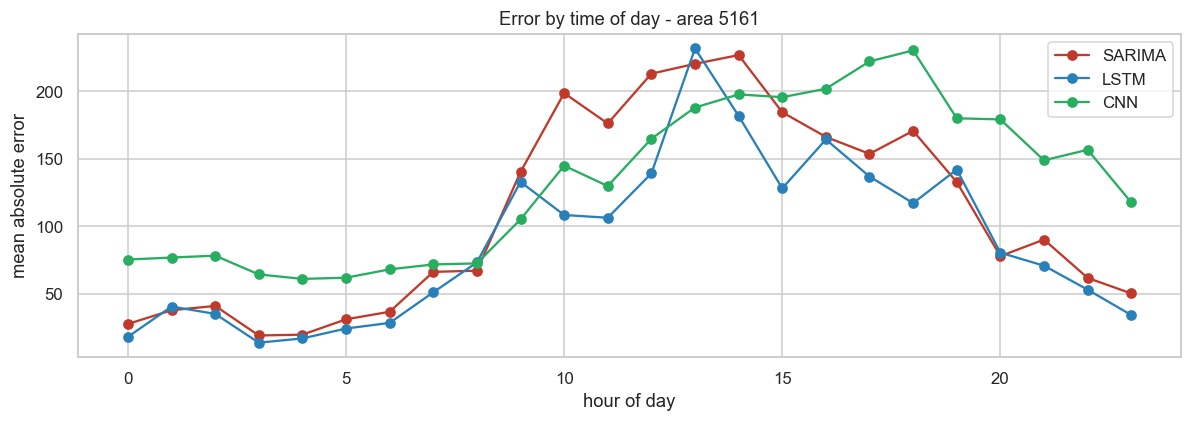

SARIMA    14
LSTM      13
CNN       18
dtype: int64

In [40]:
fail_area = TOP1_ID
idx = results[fail_area]["index"]
actual = results[fail_area]["actual"]
hourly_err = {}
hours = np.array([t.hour for t in idx])
for mname in model_names:
    err = np.abs(results[fail_area]["models"][mname]["pred"] - actual)
    hourly_err[mname] = pd.Series(err).groupby(hours).mean()
hourly_err_df = pd.DataFrame(hourly_err)

fig, ax = plt.subplots(figsize=(11, 4))
for mname in model_names:
    ax.plot(hourly_err_df.index, hourly_err_df[mname],
            marker="o", color=model_colors[mname], label=mname)
ax.set_xlabel("hour of day")
ax.set_ylabel("mean absolute error")
ax.set_title(f"Error by time of day - area {fail_area}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig08_error_by_hour.png", bbox_inches="tight")
plt.show()
hourly_err_df.idxmax()

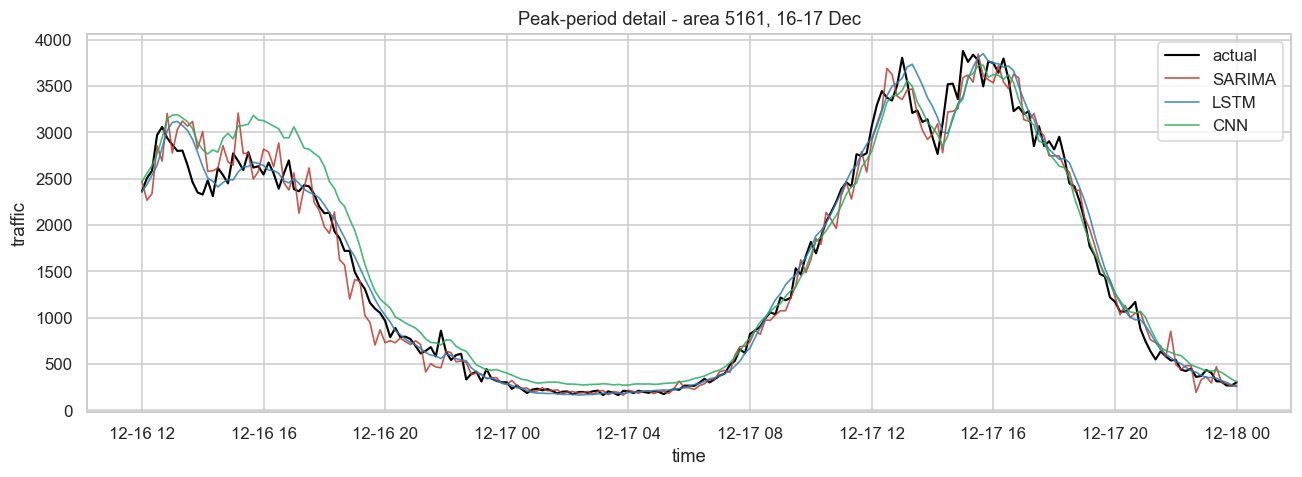

In [41]:
zoom = (idx >= pd.Timestamp("2013-12-16 12:00")) & (idx <= pd.Timestamp("2013-12-18 00:00"))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(idx[zoom], actual[zoom], color="black", linewidth=1.4, label="actual")
for mname in model_names:
    ax.plot(idx[zoom], results[fail_area]["models"][mname]["pred"][zoom],
            color=model_colors[mname], linewidth=1.1, alpha=0.85, label=mname)
ax.set_xlabel("time")
ax.set_ylabel("traffic")
ax.set_title(f"Peak-period detail - area {fail_area}, 16-17 Dec")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_peak_detail.png", bbox_inches="tight")
plt.show()

The error-by-hour analysis shows a common failure mode for all three models: accuracy is high overnight, when traffic sits in a flat, predictable trough, and degrades sharply during the busy daytime hours (roughly 10:00-18:00) when traffic is high and volatile. This confirms that errors are concentrated exactly where the EDA located the nonlinear, bursty behaviour. The peak-period detail plot makes the individual weaknesses concrete. The **CNN** is the clearest failure case: its predictions are smooth but phase-shifted, lagging the rise and overshooting on the way down, because its fixed convolutional receptive field captures the average daily shape rather than the precise timing of each peak. **SARIMA** tracks the peak level well but is visibly jittery, reflecting its linear response to short-term noise. The **LSTM** follows the peaks most faithfully, though it too slightly underestimates the very highest spikes.

The likely reasons are structural. Sharp peaks are rare, high-variance events, so squared-error training under-weights them relative to the many easy overnight points; the near-zero overnight values also inflate MAPE and make relative error unstable. Possible improvements include training on a log or power transform of the traffic to compress the peaks, adding explicit time-of-day and day-of-week features so the models need not rediscover seasonality from raw history, using a longer or multi-scale input window, and a peak-weighted loss. These directions follow directly from the observed failure pattern rather than from generic tuning.

## 11. Personal Considerations and Conclusion

### 11.1 Personal considerations on the models

Working through this comparison, the most instructive result was how demanding the persistence baseline turned out to be. At a 10-minute one-step horizon, carrying the last value forward is hard to beat because adjacent observations are so highly correlated, and this exposed that only the LSTM genuinely improves on it. SARIMA was a useful reminder that a well-matched linear model reconstructs the daily cycle cleanly, but at this horizon its short-term jitter left it slightly behind naive persistence; its value is interpretability and near-zero training cost rather than raw accuracy. The LSTM justified its complexity by being the only model to add predictive value over the baseline while staying compact (about 4,500 parameters), and its main design lever was restraint - the smallest competitive hidden size generalised best, so added capacity mostly added training time. The CNN was the most disappointing relative to its promise: even after widening the search it needed the most capacity yet remained weakest on the spikiest area, and its smooth, phase-shifted predictions suggest that a plain convolutional stack without dilated/residual depth or explicit temporal features is a poor fit for sharply peaked traffic. The clearest margin for improvement across all three is in representing the peaks and short-term dynamics - through target transformation, calendar features, or a peak-sensitive loss - rather than in raw model size.

### 11.2 Conclusion and future work

This study compared a seasonal statistical model (SARIMA), a recurrent network (LSTM) and a convolutional network (CNN) for one-step-ahead Internet-traffic forecasting on the three busiest areas of the Milan dataset, using a memory-efficient pipeline that reduced roughly 20 GB of raw text to a few hundred megabytes of Parquet and kept peak memory near the size of a single day. The exploratory analysis established the key characteristics - a heavy-tailed spatial distribution, strong daily and weekly seasonality, level stationarity, and nonlinear bursts in high-traffic cells - and these directly explained the results. The LSTM was the best model in every area and on every metric and the only one to beat a persistence baseline, SARIMA reconstructed the daily cycle but sat around baseline accuracy at this short horizon, and the CNN was competitive only in smoother areas; the ranking was stable but the performance gap widened in the spikiest, highest-traffic area, answering the research question that model suitability does vary with local traffic character. Limitations include evaluating a single week and three areas, a plain CNN rather than a full TCN, and the sensitivity of MAPE to near-zero overnight values. Future work would extend the evaluation to more areas and periods, add calendar features and target transforms to better capture peaks, incorporate spatial dependencies between neighbouring cells, and benchmark against a dilated/residual TCN and attention-based models.

## References

[1] G. Barlacchi, M. De Nadai, R. Larcher, A. Casella, C. Chitic, G. Torrisi, F. Antonelli, A. Vespignani, A. Pentland, and B. Lepri, "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Scientific Data*, vol. 2, art. 150055, 2015, doi: 10.1038/sdata.2015.55.

[2] Harvard Dataverse, "Telecommunications - SMS, Call, Internet - MI," doi: 10.7910/DVN/EGZHFV. [Online]. Available: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/EGZHFV

[3] Harvard Dataverse, "Milano Grid," doi: 10.7910/DVN/QJWLFU. [Online]. Available: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/QJWLFU

[4] H. Z. Moayedi and M. A. Masnadi-Shirazi, "ARIMA model for network traffic prediction and anomaly detection," in *Proc. Int. Symp. Information Technology*, 2008, pp. 1-6, doi: 10.1109/ITSIM.2008.4631947.

[5] S. Hochreiter and J. Schmidhuber, "Long short-term memory," *Neural Computation*, vol. 9, no. 8, pp. 1735-1780, 1997, doi: 10.1162/neco.1997.9.8.1735.

[6] C. Zhang, H. Zhang, J. Qiao, D. Yuan, and M. Zhang, "Deep transfer learning for intelligent cellular traffic prediction based on cross-domain big data," *IEEE Journal on Selected Areas in Communications*, vol. 37, no. 6, pp. 1389-1401, 2019, doi: 10.1109/JSAC.2019.2904363.

[7] S. Bai, J. Z. Kolter, and V. Koltun, "An empirical evaluation of generic convolutional and recurrent networks for sequence modeling," *arXiv:1803.01271*, 2018.

[8] C. Zhang and P. Patras, "Long-term mobile traffic forecasting using deep spatio-temporal neural networks," in *Proc. ACM MobiHoc*, 2018, pp. 231-240, doi: 10.1145/3209582.3209606.

[9] W. McKinney, "Data structures for statistical computing in Python," in *Proc. 9th Python in Science Conf. (SciPy)*, 2010, pp. 56-61, doi: 10.25080/Majora-92bf1922-00a.

[10] Apache Software Foundation, "Apache Parquet documentation." [Online]. Available: https://parquet.apache.org/docs/